Import libraries and data to be used

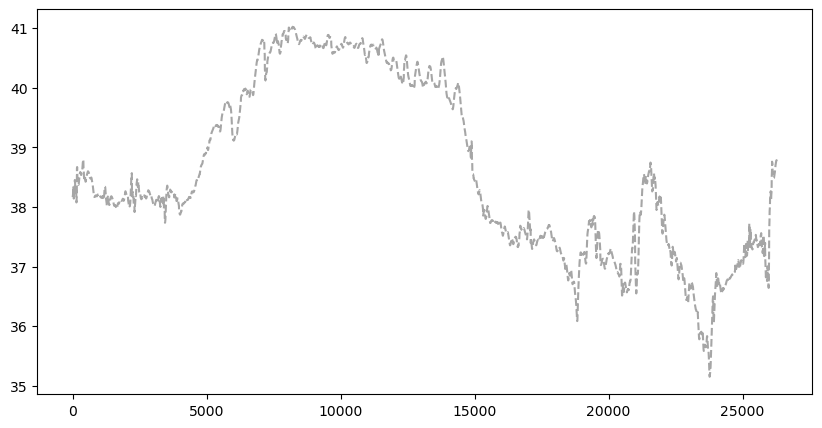

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#define the raw data paths and read in the unnormalized yaw data for L1
l1_path=r"C:\Users\awatt\OneDrive\Documents\Spine-Stiffness-Python\NGIMU_L1 - 002F29E4\euler.csv"
l1_yaw_un_norm = pd.read_csv(l1_path, skiprows=1, header=None, usecols=[3]).values

#define the raw data paths and read in the unnormalized yaw data for S1
s1_path=r"C:\Users\awatt\OneDrive\Documents\Spine-Stiffness-Python\NGIMU_S1 - 002F2E12\euler.csv"
s1_yaw_un_norm = pd.read_csv(s1_path, skiprows=1, header=None, usecols=[3]).values

#define the raw data paths and read in the unnormalized yaw data for the winch
winch_path=r"C:\Users\awatt\OneDrive\Documents\Spine-Stiffness-Python\NGIMU_Winch - 002D4F6B\euler.csv"
winch_yaw_un_norm = pd.read_csv(winch_path, skiprows=1, header=None, usecols=[3]).values

#define the raw data paths and read in the unnormalized force data
force_path=r"C:\Users\awatt\OneDrive\Documents\Spine-Stiffness-Python\FullTestForce_020422_1.txt"
force_data_raw = pd.read_csv(force_path,sep=r'\s+', header=None)

#extract the untrimmed force and event marker data from the raw force data
force_untrimmed = force_data_raw[0].values
em_untrimmed = force_data_raw[1].values


# 1. Create a figure container
plt.figure(figsize=(10, 5))

# 2. Plot the original data 
# (Since it's not normalized, we map it against its actual sample index on the X-axis)
plt.plot(l1_yaw_un_norm.flatten(), label='Original Data (Un-normalized)', color='gray', linestyle='--', alpha=0.7)
plt.show()


Time normalise all Yaw data from IMUs to make them the same length using linear interpolation

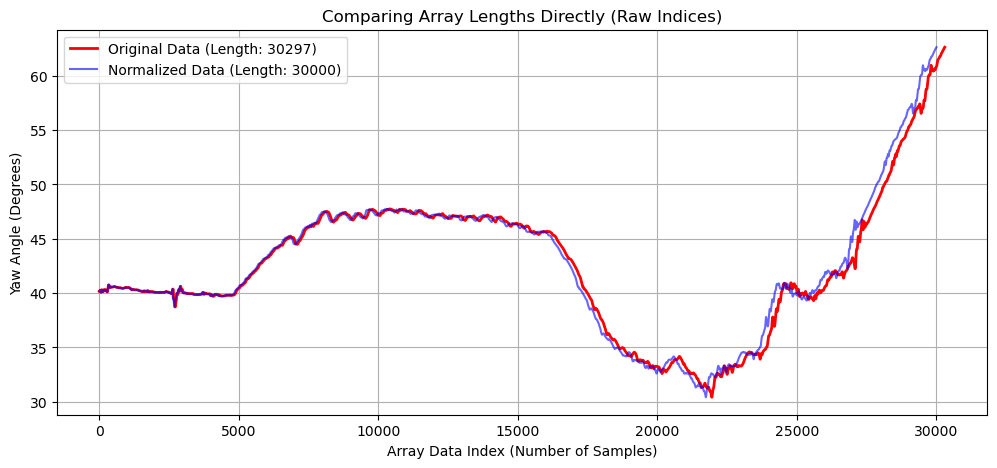

In [58]:
from scipy.interpolate import interp1d

def time_normalize_signal(x, target_length=30000):
    
    """Time-normalizes a signal to a specified target length using interpolation."""#
    x_flat=x.flatten()
    original_length=len(x_flat)
    old_time = np.arange(0, original_length)
    interpolator = interp1d(old_time, x_flat, kind='linear', bounds_error=True)
    new_time = np.linspace(0, original_length - 1, target_length)
    return interpolator(new_time)

l1_yaw_norm = time_normalize_signal(l1_yaw_un_norm)
s1_yaw_norm = time_normalize_signal(s1_yaw_un_norm)
winch_yaw_norm = time_normalize_signal(winch_yaw_un_norm)


plt.figure(figsize=(12, 5))

# Plot original data (X-axis goes up to its original length, e.g., ~1500)
plt.plot(s1_yaw_un_norm.flatten(), label=f'Original Data (Length: {len(s1_yaw_un_norm)})', color='red', linewidth=2)

# Plot normalized data (X-axis stretches all the way to 30,000)
plt.plot(s1_yaw_norm, label=f'Normalized Data (Length: {len(s1_yaw_norm)})', color='blue', alpha=0.6)

plt.title('Comparing Array Lengths Directly (Raw Indices)')
plt.xlabel('Array Data Index (Number of Samples)')
plt.ylabel('Yaw Angle (Degrees)')
plt.legend()
plt.grid(True)
plt.show()


Trim the force data to the length denoted by the start and end event markers

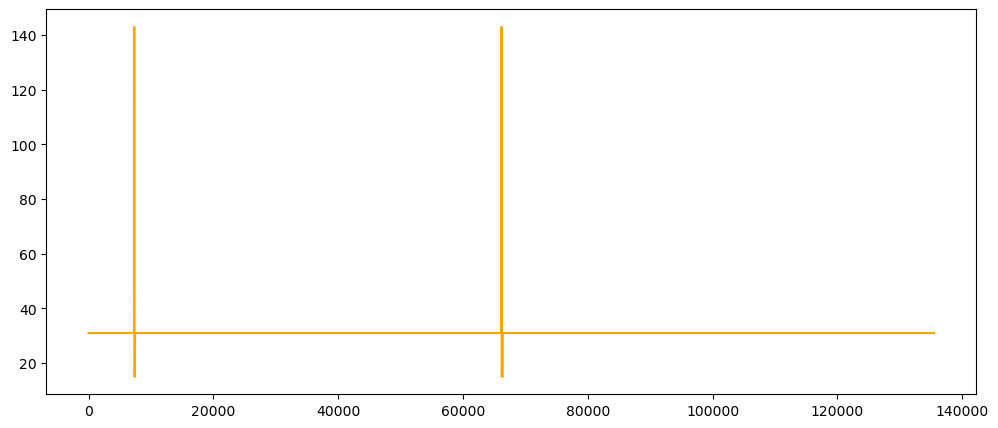

True Trial Start (First Rising Edge): 7299
True Trial End (Second Rising Edge): 66159


In [60]:
plt.figure(figsize=(12, 5))
plt.plot(em_untrimmed, label='Event Markers (Untrimmed)', color='orange')
plt.show()

# 1. Create a binary map (True/False or 1/0) of where the signal is above threshold
# Let's say your threshold is 80
threshold = 80
above_threshold = (em_untrimmed > threshold).astype(int)

# 2. Use np.diff to find where the signal JUMPS from 0 to 1
# This gives a +1 exactly at the rising edge, and a -1 at the falling edge
jumps = np.diff(above_threshold)
rising_edges = np.where(jumps == 1)[0]

# 3. Extract your true, uncorrupted start and end indices
# rising_edges[0] is the exact onset of the first spike
# rising_edges[1] is the exact onset of the second spike
start_index = rising_edges[0]
end_index = rising_edges[1]

print(f"True Trial Start (First Rising Edge): {start_index}")
print(f"True Trial End (Second Rising Edge): {end_index}")

# 4. Cleanly trim your force data
force_trimmed = force_untrimmed[start_index:end_index]